# Étape 2 — Préparation des Données & Pipeline sklearn

**Projet :** Maintenance Prédictive Industrielle  
**Tâche :** `failure_within_24h` — Classification Binaire  
**Dépôt Git :** [github.com/Vivien-Parsis/datascience-projet](https://github.com/Vivien-Parsis/datascience-projet)

---

## Table des matières

1. [Imports & Configuration](#1-imports--configuration)
2. [Chargement & Audit initial](#2-chargement--audit-initial)
3. [Détection du data leakage](#3-détection-du-data-leakage)
4. [Feature Engineering](#4-feature-engineering)
5. [Définition des features](#5-définition-des-features)
6. [Split stratifié train/test](#6-split-stratifié-traintest)
7. [Pipeline sklearn anti-leakage](#7-pipeline-sklearn-anti-leakage)
8. [Gestion du déséquilibre](#8-gestion-du-déséquilibre)
9. [Cross-validation stratifiée](#9-cross-validation-stratifiée)
10. [Visualisations](#10-visualisations)
11. [Sauvegarde des artefacts](#11-sauvegarde-des-artefacts)


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, joblib, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

sns.set_theme(style='whitegrid', palette='Set2')
COLORS = {'no_fail': '#4C9BE8', 'fail': '#E85D5D'}
TARGET = 'failure_within_24h'
ARTDIR = './artefacts'
FIGDIR = './figures/data_preparation'
for d in [ARTDIR, FIGDIR]: os.makedirs(d, exist_ok=True)

print('Imports OK')
print('ARTDIR:', ARTDIR)
print('FIGDIR:', FIGDIR)


Imports OK
ARTDIR: ./artefacts
FIGDIR: ./figures/data_preparation


## 2. Chargement & Audit initial

On charge le dataset et on affiche un premier audit : shape, types, valeurs manquantes.


In [2]:
df = pd.read_csv('./industrial_machine_maintenance.csv', parse_dates=['timestamp'])
print(f'Shape initiale : {df.shape}')
df.head()


Shape initiale : (24042, 15)


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [3]:
print('--- Types ---')
print(df.dtypes)
print('\n--- Valeurs manquantes ---')
print(df.isnull().sum())
print('\n--- Stats descriptives ---')
df.describe().round(2)


--- Types ---
timestamp                  datetime64[us]
machine_id                          int64
machine_type                          str
vibration_rms                     float64
temperature_motor                 float64
current_phase_avg                 float64
pressure_level                    float64
rpm                               float64
operating_mode                        str
hours_since_maintenance           float64
ambient_temp                      float64
rul_hours                         float64
failure_within_24h                  int64
failure_type                          str
estimated_repair_cost               int64
dtype: object

--- Valeurs manquantes ---
timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           834
current_phase_avg           731
pressure_level              924
rpm                         533
operating_mode                0
hours_since_maintenance   

,timestamp,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042,24042.00,23042.00,23208.00,23311.00,23118.00,23509.00,24042.00,24042.00,24042.00,24042.00,24042.00
mean,2024-01-08 00:06:30.111721,10.51,1.62,51.40,8.82,59.01,1144.85,172.63,13.00,27.81,0.15,608.87
min,2024-01-01 00:00:00,1.00,0.35,28.00,2.20,10.10,124.10,0.00,8.00,0.50,0.00,0.00
25%,2024-01-04 12:24:13.750000,6.00,0.82,42.61,4.63,22.70,489.40,42.87,10.50,0.50,0.00,0.00
50%,2024-01-08 00:11:30,10.00,1.27,50.06,6.43,46.30,856.00,121.61,13.00,22.57,0.00,0.00
75%,2024-01-11 13:24:32.500000,15.00,2.27,59.96,13.12,94.70,1676.00,295.58,15.50,46.41,0.00,0.00
max,2024-01-14 23:59:38,20.00,10.00,95.00,35.00,206.50,4098.80,575.63,18.00,98.34,1.00,7995.00
std,NaN,5.75,1.08,12.52,5.37,38.72,912.67,150.72,2.88,26.39,0.36,1566.79


## 3. Détection du data leakage

Avant toute modélisation, on identifie les colonnes qui révèlent directement la variable cible.

> **Colonnes à exclure :**
> - `failure_type` : intégralement aligné sur `failure_within_24h` (si `failure_type != 'none'` alors cible = 1) → **leakage critique**
> - `estimated_repair_cost` : toujours 0 quand pas de panne → **leakage**
> - `timestamp`, `machine_id` : identifiants sans signal prédictif


In [4]:
# Vérification du leakage failure_type
leakage_check = pd.crosstab(df['failure_type'], df[TARGET])
print('failure_type vs failure_within_24h :')
print(leakage_check)
print()
print('failure_type none -> target=0 toujours :', (df[df['failure_type']=='none'][TARGET] == 0).all())
print('estimated_repair_cost=0 -> target=0 toujours :', (df[df[TARGET]==0]['estimated_repair_cost']==0).all())


failure_type vs failure_within_24h :
failure_within_24h      0     1
failure_type                   
bearing                 0  1117
electrical              0   655
hydraulic               0   728
motor_overheat          0  1060
none                20482     0

failure_type none -> target=0 toujours : True
estimated_repair_cost=0 -> target=0 toujours : True


In [5]:
COLS_DROP = ['timestamp', 'machine_id', 'failure_type', 'estimated_repair_cost']
df_clean = df.drop(columns=COLS_DROP).copy()
print(f'Colonnes supprimees : {COLS_DROP}')
print(f'Shape apres suppression : {df_clean.shape}')


Colonnes supprimees : ['timestamp', 'machine_id', 'failure_type', 'estimated_repair_cost']
Shape apres suppression : (24042, 11)


## 4. Feature Engineering

On crée 3 nouvelles variables à partir des capteurs existants pour enrichir le signal prédictif.

| Feature | Formule | Justification |
|---|---|---|
| `temp_relative` | `temperature_motor − ambient_temp` | Surchauffe indépendante de la saison |
| `vibration_per_rpm` | `vibration_rms / rpm` | Vibration anormale relative à la vitesse |
| `maintenance_stress` | `log(1 + hours_since_maintenance)` | Risque croissant avec le temps |


In [6]:
# Feature 1 : temperature relative
df_clean['temp_relative'] = df_clean['temperature_motor'] - df_clean['ambient_temp']
corr1 = df_clean['temp_relative'].corr(df_clean[TARGET])
print(f'temp_relative = temperature_motor - ambient_temp')
print(f'  Correlation avec cible : {corr1:.3f}')

# Feature 2 : vibration par RPM
df_clean['vibration_per_rpm'] = df_clean['vibration_rms'] / df_clean['rpm'].clip(lower=1)
corr2 = df_clean['vibration_per_rpm'].corr(df_clean[TARGET])
print(f'vibration_per_rpm = vibration_rms / rpm')
print(f'  Correlation avec cible : {corr2:.3f}')

# Feature 3 : stress de maintenance
df_clean['maintenance_stress'] = np.log1p(df_clean['hours_since_maintenance'])
corr3 = df_clean['maintenance_stress'].corr(df_clean[TARGET])
print(f'maintenance_stress = log(1 + hours_since_maintenance)')
print(f'  Correlation avec cible : {corr3:.3f}')

print(f'\nShape apres feature engineering : {df_clean.shape}')


temp_relative = temperature_motor - ambient_temp
  Correlation avec cible : 0.375
vibration_per_rpm = vibration_rms / rpm
  Correlation avec cible : 0.317
maintenance_stress = log(1 + hours_since_maintenance)
  Correlation avec cible : 0.075

Shape apres feature engineering : (24042, 14)


## 5. Définition des features

On sépare les features numériques et catégorielles pour le ColumnTransformer.


In [7]:
NUMERIC_FEATURES = [
    'vibration_rms', 'temperature_motor', 'current_phase_avg',
    'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp',
    'rul_hours',
    # Features engineered
    'temp_relative', 'vibration_per_rpm', 'maintenance_stress'
]
CATEGORICAL_FEATURES = ['machine_type', 'operating_mode']
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df_clean[ALL_FEATURES]
y = df_clean[TARGET]

print(f'Features numeriques  ({len(NUMERIC_FEATURES)}) : {NUMERIC_FEATURES}')
print(f'Features categorielles ({len(CATEGORICAL_FEATURES)}) : {CATEGORICAL_FEATURES}')
print(f'Total : {len(ALL_FEATURES)} features | {len(y):,} observations')
print(f'Classe 1 (panne) : {y.sum():,} ({y.mean()*100:.1f}%)')


Features numeriques  (11) : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'temp_relative', 'vibration_per_rpm', 'maintenance_stress']
Features categorielles (2) : ['machine_type', 'operating_mode']
Total : 13 features | 24,042 observations
Classe 1 (panne) : 3,560 (14.8%)


## 6. Split stratifié train/test

On utilise `stratify=y` pour conserver les mêmes proportions de classes dans les deux ensembles.  
→ 14,8 % de positifs dans **train** ET dans **test**.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]:,} obs  | Test : {X_test.shape[0]:,} obs')
print(f'Train positifs : {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'Test  positifs : {y_test.sum():,}  ({y_test.mean()*100:.1f}%)')
print('Proportions preservees (stratified split)')


Train : 19,233 obs  | Test : 4,809 obs
Train positifs : 2,848 (14.8%)
Test  positifs : 712  (14.8%)
Proportions preservees (stratified split)


## 7. Pipeline sklearn anti-leakage

Le pipeline est **fitté uniquement sur `X_train`** puis appliqué (transform) sur `X_train` et `X_test`.  
Cette règle garantit qu'aucune information du test set ne contamine l'entraînement.

```
Numérique  : SimpleImputer(median) → StandardScaler
Catégoriel : SimpleImputer(mode)   → OneHotEncoder
```


In [9]:
# Sous-pipeline numerique
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Sous-pipeline categoriel
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Assemblage ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

# FIT sur train uniquement
preprocessor.fit(X_train)
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Noms des features apres OneHot
cat_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(CATEGORICAL_FEATURES)
feature_names_out = NUMERIC_FEATURES + list(cat_names)

print(f'X_train apres preprocessing : {X_train_proc.shape}')
print(f'X_test  apres preprocessing : {X_test_proc.shape}')
print(f'Features finales ({len(feature_names_out)}) : {feature_names_out}')


X_train apres preprocessing : (19233, 18)
X_test  apres preprocessing : (4809, 18)
Features finales (18) : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'temp_relative', 'vibration_per_rpm', 'maintenance_stress', 'machine_type_CNC', 'machine_type_Compressor', 'machine_type_Pump', 'machine_type_Robotic Arm', 'operating_mode_idle', 'operating_mode_normal', 'operating_mode_peak']


## 8. Gestion du déséquilibre

On compare 4 stratégies de rééchantillonnage :

| Stratégie | Principe | Avantage |
|---|---|---|
| Baseline | Aucun | Référence |
| Random OverSampling | Duplique les exemples minoritaires | Simple |
| **SMOTE** ✅ | Génère des exemples synthétiques | Diversité, moins d'overfitting |
| Random UnderSampling | Réduit la classe majoritaire | Rapide mais perd de l'info |

> **Stratégie retenue : SMOTE** — meilleur compromis diversité / qualité des données.


In [10]:
strategies = {}

# Baseline
strategies['baseline'] = (X_train_proc, y_train.values)
print(f'Baseline      : {y_train.sum():,} pos / {len(y_train):,} total ({y_train.mean()*100:.1f}%)')

# Random OverSampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train_proc, y_train)
strategies['over_sampling'] = (X_ros, y_ros)
print(f'OverSampling  : {y_ros.sum():,} pos / {len(y_ros):,} total ({y_ros.mean()*100:.1f}%)')

# SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_train_proc, y_train)
strategies['smote'] = (X_smote, y_smote)
print(f'SMOTE         : {y_smote.sum():,} pos / {len(y_smote):,} total ({y_smote.mean()*100:.1f}%)')

# Random UnderSampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_proc, y_train)
strategies['under_sampling'] = (X_rus, y_rus)
print(f'UnderSampling : {y_rus.sum():,} pos / {len(y_rus):,} total ({y_rus.mean()*100:.1f}%)')

print('\nStrategie retenue pour la modelisation : SMOTE + class_weight')


Baseline      : 2,848 pos / 19,233 total (14.8%)
OverSampling  : 16,385 pos / 32,770 total (50.0%)
SMOTE         : 16,385 pos / 32,770 total (50.0%)
UnderSampling : 2,848 pos / 5,696 total (50.0%)

Strategie retenue pour la modelisation : SMOTE + class_weight


## 9. Cross-validation stratifiée

`StratifiedKFold(n_splits=5)` préserve les proportions de classes dans chaque fold.  
Utilisée lors de l'entraînement des modèles (étape suivante).


In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('StratifiedKFold(n_splits=5) — proportions de classes preservees')
print()
for i, (_, val_idx) in enumerate(skf.split(X_train_proc, y_train)):
    fold_pos = y_train.values[val_idx].mean() * 100
    print(f'  Fold {i+1} : {len(val_idx):,} obs | {fold_pos:.1f}% positifs')


StratifiedKFold(n_splits=5) — proportions de classes preservees

  Fold 1 : 3,847 obs | 14.8% positifs
  Fold 2 : 3,847 obs | 14.8% positifs
  Fold 3 : 3,847 obs | 14.8% positifs
  Fold 4 : 3,846 obs | 14.8% positifs
  Fold 5 : 3,846 obs | 14.8% positifs


## 10. Visualisations

**Fig.8** — 6 sous-graphiques illustrant le pipeline de préparation :
- Comparaison des stratégies de rééchantillonnage
- Effet du StandardScaler sur deux capteurs
- Corrélations des features (engineered en orange)
- Split train/test et proportions
- Schéma du pipeline complet


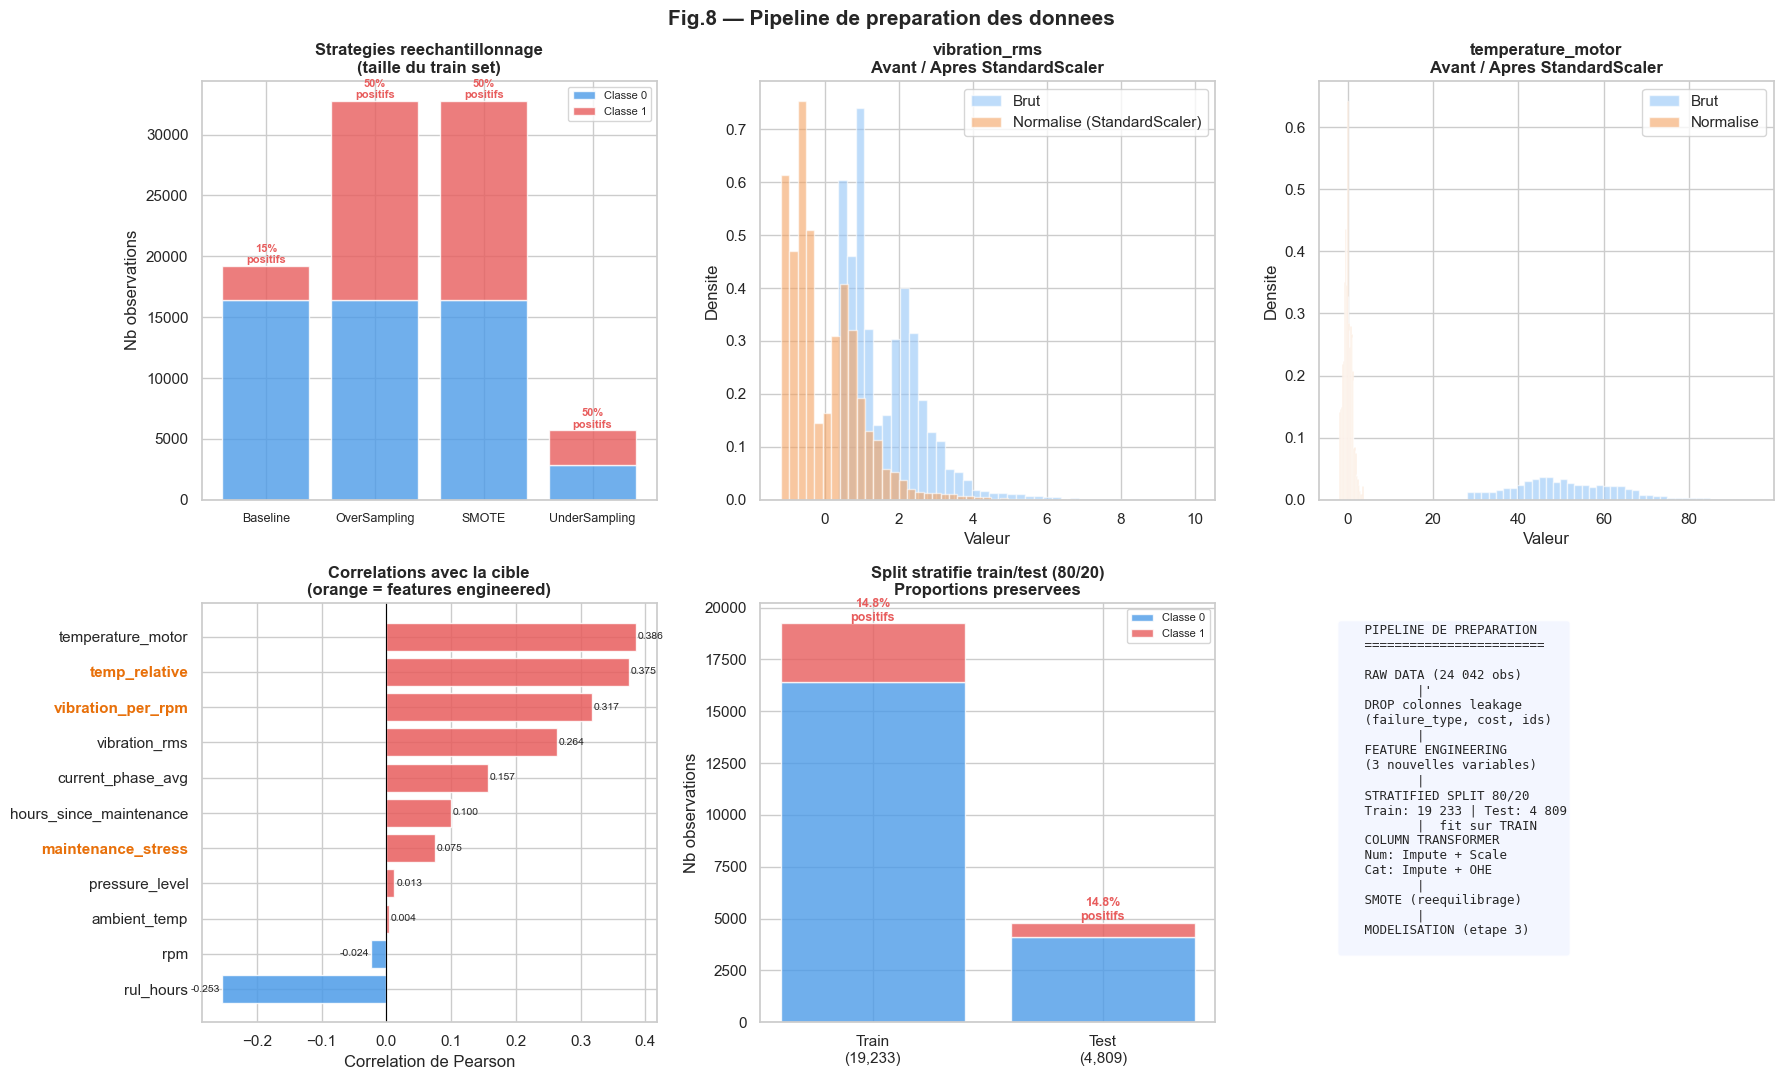

Fig.8 sauvegardee


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Fig.8 — Pipeline de preparation des donnees', fontsize=15, fontweight='bold')

# 8a — Strategies de reechantillonnage
ax = axes[0, 0]
labels  = ['Baseline', 'OverSampling', 'SMOTE', 'UnderSampling']
n_total = [len(v[1]) for v in strategies.values()]
n_pos   = [int(v[1].sum()) for v in strategies.values()]
n_neg   = [t - p for t, p in zip(n_total, n_pos)]
x = np.arange(len(labels))
ax.bar(x, n_neg, label='Classe 0', color=COLORS['no_fail'], alpha=0.8)
ax.bar(x, n_pos, bottom=n_neg, label='Classe 1', color=COLORS['fail'], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_title('Strategies reechantillonnage\n(taille du train set)', fontweight='bold')
ax.set_ylabel('Nb observations'); ax.legend(fontsize=8)
for i, (t, p) in enumerate(zip(n_total, n_pos)):
    pct = round(p/t*100)
    ax.text(i, t + 200, f'{pct}%\npositifs', ha='center', fontsize=8, fontweight='bold', color=COLORS['fail'])

# 8b — StandardScaler vibration_rms
ax = axes[0, 1]
col_idx = NUMERIC_FEATURES.index('vibration_rms')
raw_train = X_train['vibration_rms'].dropna()
scaled_train = X_train_proc[:, col_idx]
ax.hist(raw_train, bins=40, alpha=0.6, color='#94C5F8', density=True, label='Brut')
ax.hist(scaled_train, bins=40, alpha=0.6, color='#F4A261', density=True, label='Normalise (StandardScaler)')
ax.set_title('vibration_rms\nAvant / Apres StandardScaler', fontweight='bold')
ax.legend(); ax.set_xlabel('Valeur'); ax.set_ylabel('Densite')

# 8c — StandardScaler temperature_motor
ax = axes[0, 2]
col_idx2 = NUMERIC_FEATURES.index('temperature_motor')
raw2 = X_train['temperature_motor'].dropna()
scaled2 = X_train_proc[:, col_idx2]
ax.hist(raw2, bins=40, alpha=0.6, color='#94C5F8', density=True, label='Brut')
ax.hist(scaled2, bins=40, alpha=0.6, color='#F4A261', density=True, label='Normalise')
ax.set_title('temperature_motor\nAvant / Apres StandardScaler', fontweight='bold')
ax.legend(); ax.set_xlabel('Valeur'); ax.set_ylabel('Densite')

# 8d — Correlations features engineered
ax = axes[1, 0]
feat_corr = df_clean[NUMERIC_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
colors_bar = [COLORS['fail'] if v > 0 else COLORS['no_fail'] for v in feat_corr.values]
bars = ax.barh(feat_corr.index, feat_corr.values, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for i, name in enumerate(feat_corr.index):
    if name in ['temp_relative', 'vibration_per_rpm', 'maintenance_stress']:
        ax.get_yticklabels()[i].set_color('#E8700A')
        ax.get_yticklabels()[i].set_fontweight('bold')
for bar, val in zip(bars, feat_corr.values):
    ax.text(val + (0.003 if val >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=7.5)
ax.set_title('Correlations avec la cible\n(orange = features engineered)', fontweight='bold')
ax.set_xlabel('Correlation de Pearson')

# 8e — Split train/test
ax = axes[1, 1]
x = np.arange(2)
bot0 = [y_train.value_counts()[0], y_test.value_counts()[0]]
bot1 = [y_train.value_counts()[1], y_test.value_counts()[1]]
ax.bar(x, bot0, color=COLORS['no_fail'], alpha=0.8, label='Classe 0')
ax.bar(x, bot1, bottom=bot0, color=COLORS['fail'], alpha=0.8, label='Classe 1')
ax.set_xticks(x)
ax.set_xticklabels([f'Train\n({len(y_train):,})', f'Test\n({len(y_test):,})'])
for xi, (t, p) in enumerate(zip([len(y_train), len(y_test)], [y_train.sum(), y_test.sum()])):
    pct = round(p/t*100, 1)
    ax.text(xi, t + 100, f'{pct}%\npositifs', ha='center', fontsize=9, fontweight='bold', color=COLORS['fail'])
ax.set_title('Split stratifie train/test (80/20)\nProportions preservees', fontweight='bold')
ax.set_ylabel('Nb observations'); ax.legend(fontsize=8)

# 8f — Schema pipeline
ax = axes[1, 2]
ax.axis('off')
schema = (
    '   PIPELINE DE PREPARATION\n'
    '   ========================\n\n'
    '   RAW DATA (24 042 obs)\n'
    '          |\'\n'
    '   DROP colonnes leakage\n'
    '   (failure_type, cost, ids)\n'
    '          |\n'
    '   FEATURE ENGINEERING\n'
    '   (3 nouvelles variables)\n'
    '          |\n'
    '   STRATIFIED SPLIT 80/20\n'
    '   Train: 19 233 | Test: 4 809\n'
    '          |  fit sur TRAIN\n'
    '   COLUMN TRANSFORMER\n'
    '   Num: Impute + Scale\n'
    '   Cat: Impute + OHE\n'
    '          |\n'
    '   SMOTE (reequilibrage)\n'
    '          |\n'
    '   MODELISATION (etape 3)\n'
)
ax.text(0.05, 0.95, schema, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig8_preparation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig.8 sauvegardee')


## 11. Sauvegarde des artefacts

On sauvegarde tous les objets nécessaires à l'étape de modélisation et à l'API :
- `preprocessor.pkl` — pipeline sklearn fitté
- `X_train_proc.pkl`, `X_test_proc.pkl`, `y_train.pkl`, `y_test.pkl` — données transformées
- `resampling_strategies.pkl` — 4 stratégies prêtes
- `metadata.json` — configuration pour l'API


In [13]:
joblib.dump(preprocessor,       f'{ARTDIR}/preprocessor.pkl')
joblib.dump(X_train_proc,       f'{ARTDIR}/X_train_proc.pkl')
joblib.dump(X_test_proc,        f'{ARTDIR}/X_test_proc.pkl')
joblib.dump(y_train.values,     f'{ARTDIR}/y_train.pkl')
joblib.dump(y_test.values,      f'{ARTDIR}/y_test.pkl')
joblib.dump(feature_names_out,  f'{ARTDIR}/feature_names.pkl')
joblib.dump(strategies,         f'{ARTDIR}/resampling_strategies.pkl')
joblib.dump(skf,                f'{ARTDIR}/stratified_kfold.pkl')

meta = {
    'numeric_features':    NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'all_features':        ALL_FEATURES,
    'target':              TARGET,
    'n_train':             int(len(y_train)),
    'n_test':              int(len(y_test)),
    'class_balance':       {'0': int(y_train.value_counts()[0]), '1': int(y_train.value_counts()[1])},
    'dropped_columns':     COLS_DROP,
    'engineered_features': ['temp_relative', 'vibration_per_rpm', 'maintenance_stress']
}
with open(f'{ARTDIR}/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Artefacts sauvegardes :')
for fname in sorted(os.listdir(ARTDIR)):
    size = os.path.getsize(f'{ARTDIR}/{fname}')
    print(f'  {fname:<35} {size:>10,} bytes')

n_feat_in  = len(ALL_FEATURES)
n_feat_out = X_train_proc.shape[1]
print(f'\nRECAPITULATIF')
print(f'  {n_feat_in} features en entree -> {n_feat_out} apres OHE')
print(f'  Train : {X_train_proc.shape[0]:,} obs | Test : {X_test_proc.shape[0]:,} obs')
print(f'  Strategies : baseline, over_sampling, smote, under_sampling')
print(f'  Artefacts dans : {ARTDIR}')
print('\nPREPARATION TERMINEE - Pret pour la modelisation')


Artefacts sauvegardes :
  X_test_proc.pkl                        692,737 bytes
  X_train_proc.pkl                     2,769,793 bytes
  best_model.pkl                       7,845,161 bytes
  comparison_table.pkl                     3,871 bytes
  feature_importance.pkl                   2,107 bytes
  feature_names.pkl                          365 bytes
  metadata.json                            1,051 bytes
  model_gradient_boosting.pkl            834,313 bytes
  model_logistic_regression.pkl            1,007 bytes
  model_mlp_deep_learning.pkl            316,456 bytes
  model_random_forest.pkl              7,845,161 bytes
  preprocessor.pkl                         4,458 bytes
  resampling_strategies.pkl           14,322,797 bytes
  results.json                             1,328 bytes
  stratified_kfold.pkl                       114 bytes
  y_test.pkl                              38,697 bytes
  y_train.pkl                            154,089 bytes

RECAPITULATIF
  13 features en entree ->